# アクティビティモデル
アクティビティモデルの一つである離散連続モデルを用いて活動時間配分の推定を行います．
## データの説明
ここでは，2021年7月-8月に首都圏に住んでいる方々を主な対象として行ったPP調査のデータです．今回はそれを離散連続モデルが使えるように加工したデータを用います．
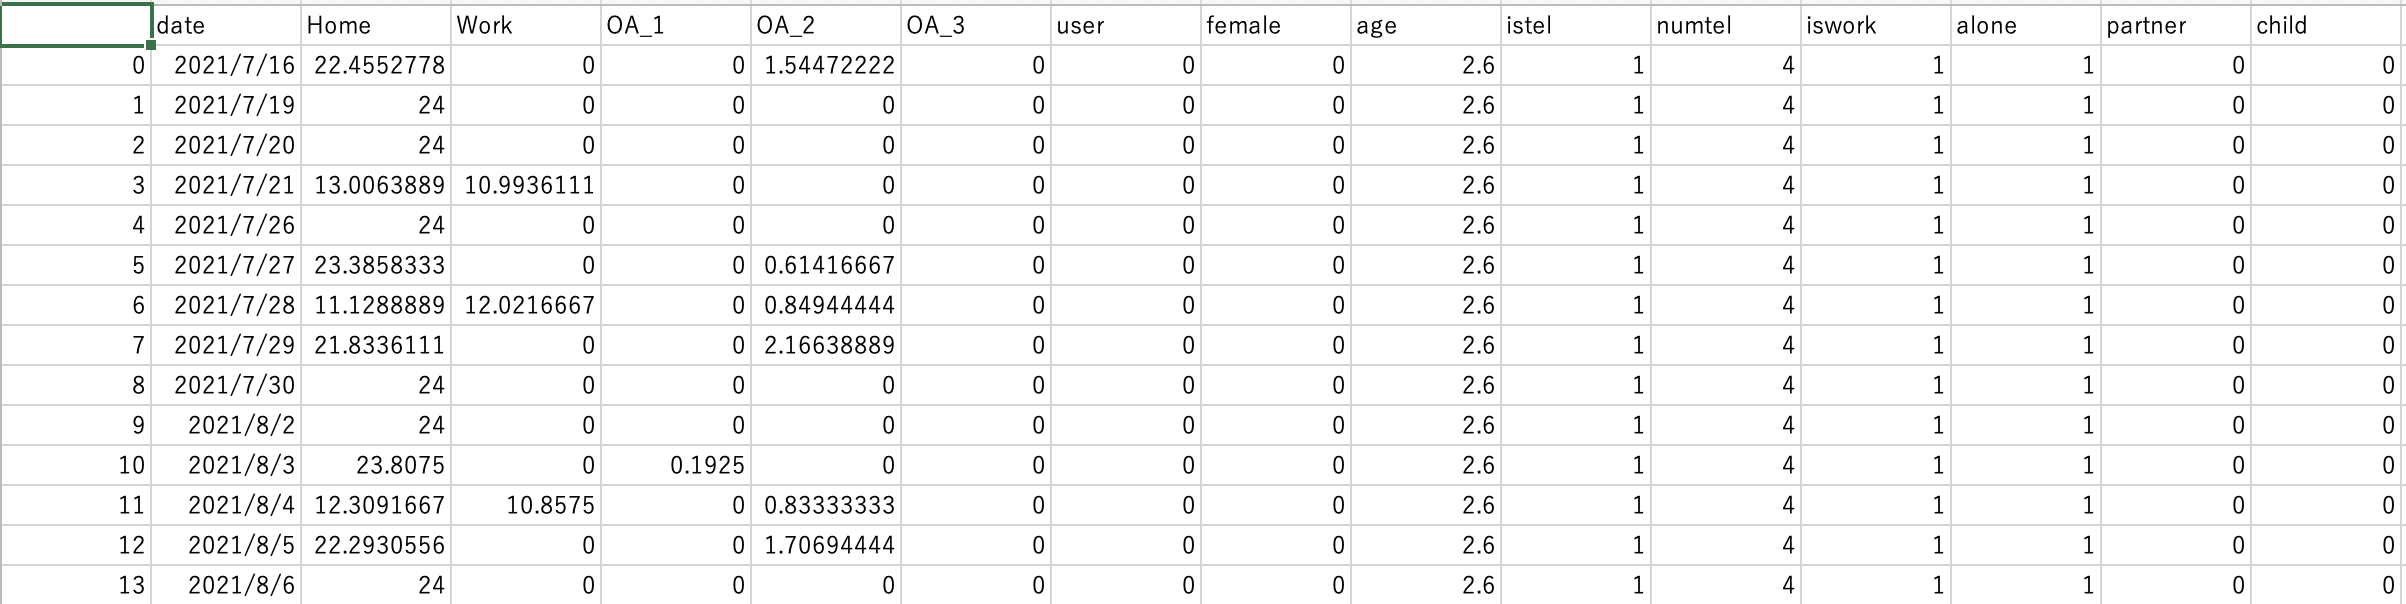

今回渡したデータは，各トリップでどのリンクにどれだけ滞在したか（行数カウント）を表すものです．

それぞれの列の説明です．

**リンク滞在時間（行数カウント）**
*   link1, link2, ..., linkN：各リンクでの滞在時間（同じリンクが連続している場合は行数分を加算）
*   link列はlink_idの昇順で並んでいます（link1が最小のlink_id）
*   end：滞在終了の活動（最大遷移数Tに満たない分を割り当て）

**リンク属性（link.csv由来）**
*   length, capacity, park_ave, first_st, gate_st, national_rd, parking, plaza_stay, type_stay を説明変数として使用
*   endは定数項（end_const）のみ




# **注意：データの利用について**
本データは交通研が取得したデータであり，利用目的は**本研究室の研究や教育活動への利活用のみ**となっています．本データをそれ以外の目的で使わないようお願いします．

# ロジットモデル推定のための準備

In [1]:
from inspect import signature
import json
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import time

#Generalなlogitmodel推定のためのクラス
class LogitModel:
    def __init__(self, f, parameter_names=None, vector_mode=False):
        self.f = f
        self.vector_mode = vector_mode
        if parameter_names is None:
            self.parameters = list(signature(self.f).parameters)
        else:
            self.parameters = parameter_names
        self.n = len(self.parameters)
        self.x0 = [0] * self.n
        if self.vector_mode:
            self.mf = lambda x: -self.f(x)
        else:
            self.mf = lambda x: -self.f(*x)

    def hessian(self, h):
        x = self.res.x
        res = np.zeros((self.n, self.n))
        for i in range(self.n):
            for j in range(i, self.n):
                #print(f'i:{i}, j:{j}')
                e_i, e_j = np.zeros(self.n), np.zeros(self.n)
                e_i[i] = 1
                e_j[j] = 1

                # mfは符号が逆転しているので数値微分も符号逆にする
                res[i,j] = (
                                    - self.mf(x + h * e_i + h * e_j)
                                    + self.mf(x + h * e_i - h * e_j)
                                    + self.mf(x - h * e_i + h * e_j)
                                    - self.mf(x - h * e_i - h * e_j)
                            ) / (4 * h * h)
                res[j,i] = res[i,j]
        return res

    def tval(self, h):
        #print(self.hessian(h))
        return self.res.x / np.sqrt(-np.diag(np.linalg.inv(self.hessian(h))))

    def _minimize(self):
        return minimize(self.mf, self.x0, method="BFGS")

    def calc(self, h=10 ** -4):
        start_time = time.time()
        self.res = self._minimize()
        print('End')
        print(self.res.x)
        end_time = time.time()
        elapsed_time = end_time - start_time
        print(f"time: {elapsed_time}s")
        self.res.tval = self.tval(h)
        L0 = - self.mf(self.x0)
        LL = - self.res.fun
        self.res.L0 = L0
        self.res.likelihood = (L0 - LL) / L0
        self.res.adjusted_likelihood = (L0 - (LL - self.n)) / L0
        return self.res


    def result_table(self):
        df_result = pd.DataFrame(index=self.parameters)
        df_result["x"] = self.res.x
        df_result["tval"] = self.res.tval
        return df_result

    def result_to_json(self, file_name: str):
        with open(file_name, "w", encoding="utf-8") as f:
            json.dump(dict(zip(self.parameters, self.res.x)), f)

#MDCEV推定のためのクラス
class LogitModelBound_gamma(LogitModel):
    def __init__(self, f, bound_idx=tuple(), parameter_names=None, vector_mode=False):
        super().__init__(f, parameter_names=parameter_names, vector_mode=vector_mode)
        self.bound_idx = bound_idx
        for idx in self.bound_idx:
            self.x0[idx] = 1

    def _minimize(self):
        bounds = list(((None, None),) * self.n)
        for idx in self.bound_idx:
            bounds[idx] = (0.001, 100)
        print(self.x0)
        print(bounds)
        return minimize(self.mf, self.x0, bounds=bounds,method="L-BFGS-B")


## 推定の前処理

In [2]:
#必要なライブラリのインポート
import numpy as np
import pandas as pd
import math
import inspect
import matplotlib.pyplot as plt

In [3]:
#データセットの読み込み
df = pd.read_csv('/home/mizutani/projects/RF/0128MDCEV/data/input/mdcev_from_synthetic.csv', index_col = 0)
#パスは左側の「ファイル」タブから「drive→MyDrive」と進んでいき，mdcev_dataset.csvがあるところまで進んでいき，見つけたら右クリックでで「パスをコピー」で入手できます．

#MNLより推定に時間がかかるので，とりあえず上から500データ取り出しています．これで計算時間は2分くらい
#本格的な推定をしたい場合はデータセットを全て使うと良いです．
df = df.head(500)

#リンク属性の読み込み
link_df = pd.read_csv('/home/mizutani/projects/RF/0128MDCEV/data/input/link.csv')

In [4]:
df

,link1,link2,link3,link4,link5,link6,link7,link8,link9,link10,...,link75,link76,link77,link78,link79,link80,link81,link82,link83,end
0,0,1,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,33
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,33
2,0,0,0,0,0,0,0,0,0,0,...,0,1,4,0,0,0,0,0,1,33
3,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,30
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,35
496,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,28
497,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,35
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,34


## MDCEVの定式化

各リンク（link1, link2, ..., linkN）への滞在時間の配分をモデル化します．
（γは全リンク共通とします）

時間の重みは同じなので，$\forall k, p_k=1$が成立します．そして，この時$\sigma = 1$と正規化して良いことが知られています．そして推定のために$\alpha_k\to 0$とします．これらの簡略化により選択確率は

\begin{equation}
\prod_{i=1}^M\frac{1}{x_i^* + \gamma_i}\sum_{i=1}^M (x_i^* + \gamma_i)\frac{\prod_{i=1}^M \exp(V_i)}{(\sum_{k=1}^{K} \exp(V_i))^M}(M-1)!
\end{equation}
(ただし，$V_k = \beta z_k - \ln (\frac{x_k^*}{\gamma_k}+1)$である)
となります．


In [5]:
#定式化

#選択確率を求める関数
def prob_mdcev_gamma(costs: list[float], V: list[float], uses: list[bool], gammas: list[float]) -> float:
    assert len(costs) == len(V) == len(gammas) == len(uses)
    M = uses.count(True)

    costs_use = [cost for cost, flag in zip(costs, uses) if flag]
    gamma_use = [gamma for gamma, flag in zip(gammas, uses) if flag]
    V_use = [v for v, flag in zip(V, uses) if flag]

    prod_1 = math.prod((1 / (cost + gamma)) for cost, gamma in zip(costs_use, gamma_use))
    sum_1 = sum((cost + gamma) for cost, gamma in zip(costs_use, gamma_use))
    sum_2 = sum(math.exp(v) for v in V)
    prod_2 = math.prod(math.exp(v) / sum_2 for v in V_use)
    return prod_1 * sum_1 * prod_2 * math.factorial(M - 1)

In [6]:
# link列の抽出
link_cols = [col for col in df.columns if col.startswith("link")]
choice_cols = link_cols + ["end"]
K = len(choice_cols)

# link.csv から説明変数を作成
link_df = link_df.copy()
link_df["end_const"] = 0.0
link_df["type_stay"] = (link_df["type"] == "stay").astype(int)
feature_cols = [
    "end_const",
    #"length",
    #"capacity",
    "park_ave",
    "first_st",
    "gate_st",
    "national_rd",
    "parking",
    "plaza_stay",
    #"type_stay",
]

link_features = link_df.set_index("link_id")[feature_cols]

synthetic_link_ids = (
    pd.read_csv(
        '/home/mizutani/projects/RF/0128MDCEV/data/input/synthetic_data.csv',
        usecols=["link_id"],
    )["link_id"].drop_duplicates().sort_values().tolist()
)

missing_in_link = set(synthetic_link_ids) - set(link_features.index)
if missing_in_link:
    raise ValueError(f"link.csvに存在しないlink_idがあります: {sorted(missing_in_link)}")
if len(synthetic_link_ids) != len(link_cols):
    raise ValueError(
        f"link_id数が一致しません。synthetic={len(synthetic_link_ids)}, data={len(link_cols)}"
    )

link_feature_by_col = pd.DataFrame(
    link_features.loc[synthetic_link_ids].values,
    index=link_cols,
    columns=feature_cols,
)

end_feature = pd.DataFrame(
    [[1.0] + [0.0] * (len(feature_cols) - 1)],
    index=["end"],
    columns=feature_cols,
)

X = pd.concat([link_feature_by_col, end_feature], axis=0).values

#βとγからVを求め，prob_mdcev_gammaに引き渡す関数
def prob_V_link(costs: list[float], uses: list[bool], gamma: float, params: list[float]) -> float:
    assert len(costs) == len(uses)
    params_arr = np.array(params)
    V = (X @ params_arr).tolist()
    V = [v - math.log(cost / gamma + 1) for v, cost in zip(V, costs)]
    return prob_mdcev_gamma(
        costs=costs,
        V=V,
        uses=uses,
        gammas=[gamma] * len(costs),
    )

In [7]:
link_df

,link_id,fid,O,D,type,length,capacity,park_ave,first_st,gate_st,national_rd,parking,plaza_stay,end_const,type_stay
0,0,0,0,1,move,1.0,1000.0,0,0,0,1,0,0,0.0,0
1,1,1,0,2,move,1.0,1000.0,0,0,0,1,0,0,0.0,0
2,2,2,0,4,move,1.0,1000.0,0,1,0,0,0,0,0.0,0
3,3,3,0,11,move,1.0,1000.0,0,1,1,0,0,0,0.0,0
4,4,4,0,0,stay,1.0,1000.0,0,0,0,0,0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,80,80,17,18,move,1.0,1000.0,1,0,0,0,0,0,0.0,0
81,81,81,17,17,stay,1.0,1000.0,0,0,0,0,0,0,0.0,1
82,82,82,18,16,move,1.0,1000.0,1,0,0,0,0,0,0.0,0
83,83,83,18,17,move,1.0,1000.0,0,0,0,0,1,0,0.0,0


In [8]:
#対数尤度を計算する関数
def likelihood(params: list[float]):
    #gammaと定数項を分割
    gamma = params[0]
    betas = params[1:]

    #対数尤度の初期化
    log_likelihood = 0

    for i in df.index:
        #コストを取り出す
        costs = [df.loc[i, col] for col in choice_cols]
        uses = [bool(cost) for cost in costs]

        #選択確率を対数尤度に追加
        log_likelihood += math.log(
            prob_V_link(
                costs=costs,
                uses=uses,
                gamma=gamma,
                params=betas,
            )
        )
    print(params)
    print(f"log_likelihood:{log_likelihood}")
    return log_likelihood

# 推定

In [9]:
# link.csv をデータ側のlink_idに合わせて絞り込む
synthetic_link_ids = (
    pd.read_csv(
        '/home/mizutani/projects/RF/0128MDCEV/data/input/synthetic_data.csv',
        usecols=["link_id"],
    )["link_id"].drop_duplicates().sort_values().tolist()
)
link_df = link_df[link_df["link_id"].isin(synthetic_link_ids)].copy()


In [10]:
param_names = ["gamma"] + [f"beta_{col}" for col in feature_cols]
gamma_idx = (0,)
LL = LogitModelBound_gamma(
    likelihood,
    bound_idx=gamma_idx,
    parameter_names=param_names,
    vector_mode=True,
)
LL.calc()
print(LL.result_table())

[1, 0, 0, 0, 0, 0, 0, 0]
[(0.001, 100), (None, None), (None, None), (None, None), (None, None), (None, None), (None, None), (None, None)]
[1. 0. 0. 0. 0. 0. 0. 0.]
log_likelihood:-18536.429772774845
[1.00000001 0.         0.         0.         0.         0.
 0.         0.        ]
log_likelihood:-18536.42976444788
[1.e+00 1.e-08 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
log_likelihood:-18536.429767788377
[1.e+00 0.e+00 1.e-08 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00]
log_likelihood:-18536.42977451801
[1.e+00 0.e+00 0.e+00 1.e-08 0.e+00 0.e+00 0.e+00 0.e+00]
log_likelihood:-18536.429776420522
[1.e+00 0.e+00 0.e+00 0.e+00 1.e-08 0.e+00 0.e+00 0.e+00]
log_likelihood:-18536.429773241944
[1.e+00 0.e+00 0.e+00 0.e+00 0.e+00 1.e-08 0.e+00 0.e+00]
log_likelihood:-18536.42977511296
[1.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 1.e-08 0.e+00]
log_likelihood:-18536.42977551871
[1.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 0.e+00 1.e-08]
log_likelihood:-18536.42977016542
[ 1.12553045  0.6322764  -0.22103035 

In [11]:
#初期尤度
print(f'initial_lilelihood:{LL.res.L0}')
#最終尤度
print(f'final_liklelihood:{- LL.res.fun}')
#尤度比

print(f'liklelihood_ratio:{LL.res.likelihood}')
#修正済み尤度比
print(f'adjusted_liklelihood_ratio:{LL.res.adjusted_likelihood}')

initial_lilelihood:-18536.429772774845
final_liklelihood:-15434.768507883262
liklelihood_ratio:0.1673278674972842
adjusted_liklelihood_ratio:0.16689628492728198


In [13]:
#結果を保存
LL.result_table().to_csv('/home/mizutani/projects/RF/0128MDCEV/data/output/res.csv')

In [14]:
param_df = LL.result_table()

In [15]:
LL.result_table()

,x,tval
gamma,1.278439,36.900992
beta_end_const,5.348832,88.897075
beta_park_ave,-0.934597,-12.305151
beta_first_st,-0.617387,-13.685126
beta_gate_st,-0.166150,-1.435343
beta_national_rd,-0.873360,-13.656512
beta_parking,-2.612656,-14.330035
beta_plaza_stay,0.880818,14.488846


# 可視化

In [16]:
#パラメータが与えられた時にシミュレーションの結果を出力
def simulation(total_time):
    K = len(choice_cols)
    #Step1:すべての選択肢のpsiを計算する．
    #外部財はガンベル分布からのランダムドローのみ
    rng = np.random.default_rng()
    gumbel_lis = rng.gumbel(loc=0, scale=1, size=K + 1)

    psi_out = math.exp(gumbel_lis[0])
    betas = np.array([param_df.loc[f"beta_{col}", "x"] for col in feature_cols])
    gamma = float(param_df.loc["gamma", "x"])
    psi_links = np.exp(X @ betas + gumbel_lis[1:])

    #Step2 psiを大きい順に並べる(外部財は除く)
    arr = psi_links
    sorted_arr = np.sort(arr)[::-1]
    indices = np.argsort(arr)[::-1]
    indices_reverse = np.argsort(indices)
    sorted_gamma_arr = np.full(K, gamma)[indices]
    psi_gamma = np.multiply(sorted_arr, sorted_gamma_arr)

    #Step3
    #最初はM=0とする
    M = 0
    E = total_time
    comp = sorted_arr[0]
    lambda_an = psi_out / E
    sum_gamma = 0
    sum_psi_gamma = 0
    #lambdaを計算
    while lambda_an < comp:
        M += 1
        ## 上位M個を取り出す
        sum_gamma = np.sum(sorted_gamma_arr[:M])
        sum_psi_gamma = np.sum(psi_gamma[:M])

        lambda_an = (psi_out + sum_psi_gamma) / (E + sum_gamma)
        if M == K:
            break
        else:
            comp = sorted_arr[M]

    #選択されたM個がわかったのでそれを用いて計算する
    x_arr = np.zeros(K)
    #2個目~M個目
    for i in range(M):
        x_arr[i] = (sorted_arr[i] * (E + sum_gamma) / (psi_out + sum_psi_gamma) - 1) * sorted_gamma_arr[i]

    #x_arrをもとの順番にrearrangeする
    x_arr_rearrange = x_arr[indices_reverse]
    return x_arr_rearrange

def make_simulation_data(rep, total_time):
    arr = simulation(total_time)
    for _ in range(rep - 1):
        arr_append = simulation(total_time)
        arr = np.vstack((arr, arr_append))
    return arr



In [17]:
res_arr = make_simulation_data(1000, 41)
df = pd.DataFrame(res_arr, columns=choice_cols)

In [18]:
df

,link1,link2,link3,link4,link5,link6,link7,link8,link9,link10,...,link75,link76,link77,link78,link79,link80,link81,link82,link83,end
0,1.023377,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,3.95456,0.0,0.000000,0.0,0.000000,0.000000,19.173559
1,0.000000,0.25032,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,13.035603
2,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,2.376599,0.0,0.000000,0.000000,22.816554
3,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,11.381680
4,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,5.916683,0.00000,0.0,0.000000,0.0,0.096399,0.000000,34.237860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,35.812668
996,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,14.719806
997,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.940313,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,27.370589
998,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,3.756379,0.00000,0.0,0.000000,0.0,0.000000,0.000000,37.051681


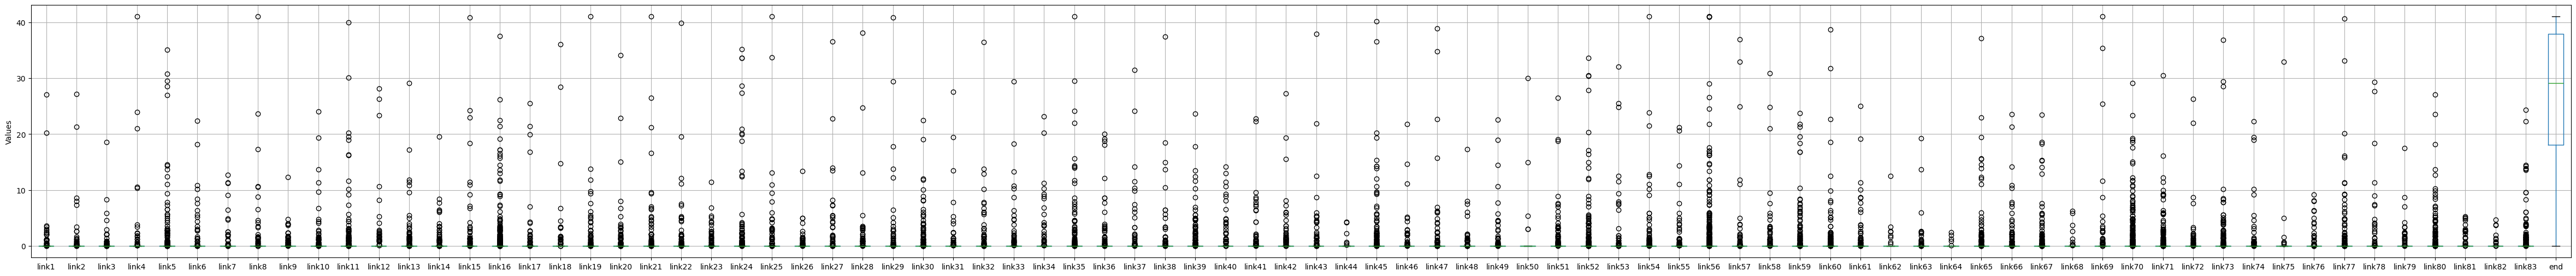

In [20]:
#それぞれの箱ヒゲ図
plt.figure(figsize=(60, 6))
df.boxplot()
plt.ylabel('Values')
plt.show()

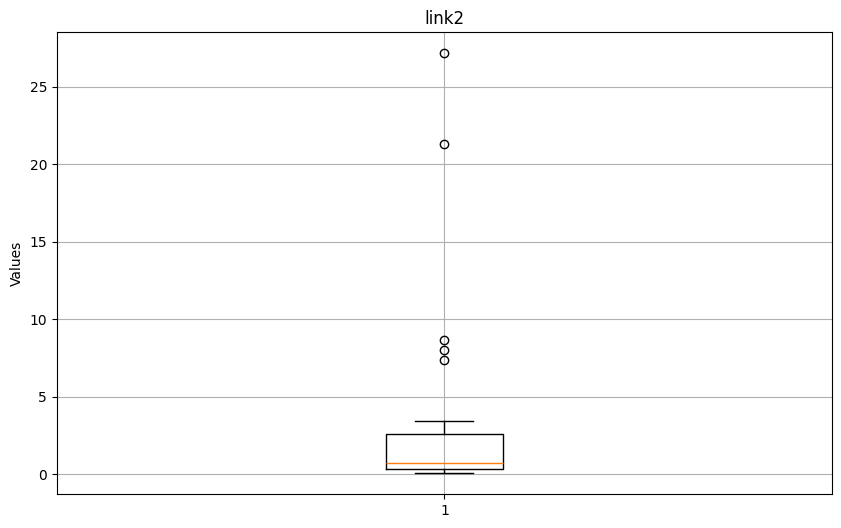

In [21]:
#一部のリンクについて違いがわからないので0のデータを抜いて可視化してみると良い
target_id = 1
target_col = link_cols[target_id]
lis = df[df[target_col] != 0][target_col].tolist()
# 箱ひげ図の作成
plt.figure(figsize=(10, 6))
plt.boxplot(lis)
plt.title(target_col)
plt.ylabel('Values')
plt.grid(True)
plt.show()


In [22]:
df.columns

Index(['link1', 'link2', 'link3', 'link4', 'link5', 'link6', 'link7', 'link8',
       'link9', 'link10', 'link11', 'link12', 'link13', 'link14', 'link15',
       'link16', 'link17', 'link18', 'link19', 'link20', 'link21', 'link22',
       'link23', 'link24', 'link25', 'link26', 'link27', 'link28', 'link29',
       'link30', 'link31', 'link32', 'link33', 'link34', 'link35', 'link36',
       'link37', 'link38', 'link39', 'link40', 'link41', 'link42', 'link43',
       'link44', 'link45', 'link46', 'link47', 'link48', 'link49', 'link50',
       'link51', 'link52', 'link53', 'link54', 'link55', 'link56', 'link57',
       'link58', 'link59', 'link60', 'link61', 'link62', 'link63', 'link64',
       'link65', 'link66', 'link67', 'link68', 'link69', 'link70', 'link71',
       'link72', 'link73', 'link74', 'link75', 'link76', 'link77', 'link78',
       'link79', 'link80', 'link81', 'link82', 'link83', 'end'],
      dtype='str')

In [23]:
df.to_csv('/home/mizutani/projects/RF/0128MDCEV/data/output/mdcev_link.csv')

In [24]:
link_df

,link_id,fid,O,D,type,length,capacity,park_ave,first_st,gate_st,national_rd,parking,plaza_stay,end_const,type_stay
0,0,0,0,1,move,1.0,1000.0,0,0,0,1,0,0,0.0,0
1,1,1,0,2,move,1.0,1000.0,0,0,0,1,0,0,0.0,0
2,2,2,0,4,move,1.0,1000.0,0,1,0,0,0,0,0.0,0
3,3,3,0,11,move,1.0,1000.0,0,1,1,0,0,0,0.0,0
4,4,4,0,0,stay,1.0,1000.0,0,0,0,0,0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,80,80,17,18,move,1.0,1000.0,1,0,0,0,0,0,0.0,0
81,81,81,17,17,stay,1.0,1000.0,0,0,0,0,0,0,0.0,1
82,82,82,18,16,move,1.0,1000.0,1,0,0,0,0,0,0.0,0
83,83,83,18,17,move,1.0,1000.0,0,0,0,0,1,0,0.0,0


In [25]:
df

,link1,link2,link3,link4,link5,link6,link7,link8,link9,link10,...,link75,link76,link77,link78,link79,link80,link81,link82,link83,end
0,1.023377,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,3.95456,0.0,0.000000,0.0,0.000000,0.000000,19.173559
1,0.000000,0.25032,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,13.035603
2,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,2.376599,0.0,0.000000,0.000000,22.816554
3,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,11.381680
4,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,5.916683,0.00000,0.0,0.000000,0.0,0.096399,0.000000,34.237860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,35.812668
996,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,14.719806
997,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.940313,0.0,0.0,...,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.0,0.000000,0.000000,27.370589
998,0.000000,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,3.756379,0.00000,0.0,0.000000,0.0,0.000000,0.000000,37.051681


In [26]:
df.mean(axis=0)

link1      0.082871
link2      0.093583
link3      0.056232
link4      0.128184
link5      0.352113
            ...    
link80     0.267682
link81     0.046690
link82     0.019068
link83     0.245222
end       26.935383
Length: 84, dtype: float64

In [27]:
# dfの列の平均をとって新しいdataframeにする
mdcev_node = df.mean(axis=0).to_frame()
# 各列の最大値で正規化
#max_value = df.max(axis=0)
#mdcev_node = mdcev_node.div(max_value, axis=0)

mdcev_node.columns = ["value"]
mdcev_node["link_id"] = mdcev_node.index.str[4:]
mdcev_node = mdcev_node.reset_index(drop=True)
mdcev_node = mdcev_node.iloc[:-1,:]
mdcev_node

,value,link_id
0,0.082871,1
1,0.093583,2
2,0.056232,3
3,0.128184,4
4,0.352113,5
...,...,...
78,0.068974,79
79,0.267682,80
80,0.046690,81
81,0.019068,82


In [28]:
mdcev_node["node_id"] = 0
for idx, row in mdcev_node.iterrows():
    matches = link_df.loc[link_df["link_id"].astype(str) == str(row["link_id"]), "O"]
    if not matches.empty:
        mdcev_node.loc[idx, "node_id"] = matches.values[0]
    else:
        print(f"Warning: link_id {row['link_id']} not found in link_df")
        
# mdcev_nodeをnodeごとに集計
mdcev_node_grouped = mdcev_node.groupby("node_id")["value"].sum().reset_index()
mdcev_node_grouped


,node_id,value
0,0,0.640046
1,1,0.898680
2,2,0.882015
3,4,1.455806
4,5,1.029233
5,6,0.890242
6,8,0.674814
7,9,0.914119
8,10,1.041526
9,11,1.215700


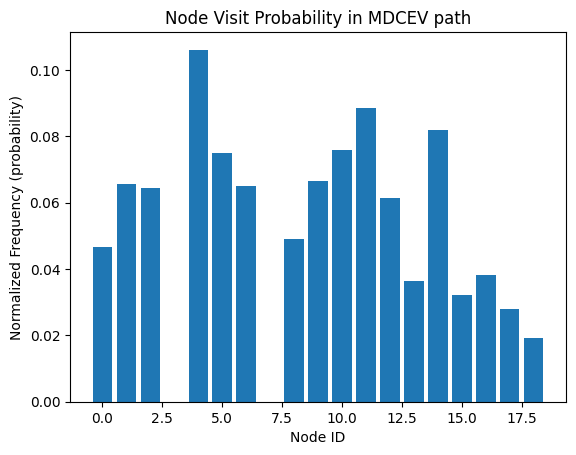

In [29]:
# mdcev_node_groupedをヒストグラムに。横軸がnode_id,縦軸がvalue
plt.figure()
plt.bar(mdcev_node_grouped["node_id"], mdcev_node_grouped["value"]/mdcev_node_grouped["value"].sum())
plt.xlabel("Node ID")
plt.ylabel("Normalized Frequency (probability)")
plt.title("Node Visit Probability in MDCEV path")
plt.show()


In [84]:
mdcev_node_grouped.to_csv('/Users/masudasatoki/Downloads/okinawa_routechoice/data/output/mdcev_node.csv')